In [14]:
# Analysis by Abel Wondem

In [15]:
# Put all required library and package here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from scipy.stats import norm

# Task 1 Stratified Sampling

In [16]:
# input dataset
airline_stats = pd.read_csv("airline_stats (1).csv")
print(airline_stats.head())

   pct_carrier_delay  pct_atc_delay  pct_weather_delay   airline
0           8.153226       1.971774           0.762097  American
1           5.959924       3.706107           1.585878  American
2           7.157270       2.706231           2.026706  American
3          12.100000      11.033333           0.000000  American
4           7.333333       3.365591           1.774194  American


In [17]:
def cal_explore(dataset, var):
  # find the mode of var
  mode = dataset[var].mode()
  # Calculate the probability of each category
  prob = dataset[var].value_counts(normalize=True)

  print(f'\nexploration of {var}')
  print(f'mode: {mode}')
  print(f'probability: {prob}')


  # Plot a bar chart
  fig_bar, ax_bar = plt.subplots(figsize=(4, 4))
  ax_bar = prob.plot.bar(legend = True)

  # Step 3: Customize and display the chart
  ax_bar.set_xlabel(var)
  ax_bar.set_ylabel('Probability')

  plt.show() # Display the current plot


exploration of airline
mode: 0    Delta
Name: airline, dtype: object
probability: airline
Delta        0.272111
American     0.171059
Southwest    0.166846
United       0.162125
Alaska       0.115065
Jet Blue     0.112794
Name: proportion, dtype: float64


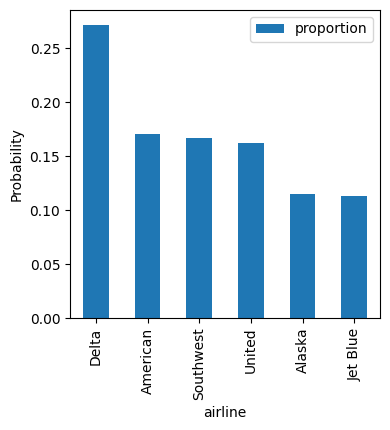

In [18]:
# bar chart for original dataset
cal_explore(airline_stats, 'airline')

In [19]:
column_list = airline_stats['airline']

# Stratified sampling made
stratified_sample = resample(
    airline_stats,
    replace=False,
    n_samples=round(len(airline_stats) * 0.20),
    stratify=column_list,
    random_state=42
)


exploration of airline
mode: 0    Delta
Name: airline, dtype: object
probability: airline
Delta        0.272184
American     0.171049
Southwest    0.166866
United       0.162085
Alaska       0.115028
Jet Blue     0.112788
Name: proportion, dtype: float64


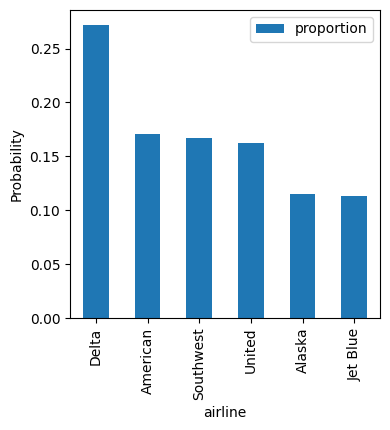

In [20]:
# Display the shape of the stratified sample
cal_explore(stratified_sample, 'airline')

# Task 2 Bootstrap

In [21]:
# bootstrap dataset
results = []
for nrepeat in range(1000):
    sample = resample(
        airline_stats['pct_atc_delay'].dropna(),
        replace=True,
        random_state=nrepeat
    )
    results.append(sample.mean())
results_table = pd.DataFrame(results, columns=['sample_mean'])
print(results_table.head())

   sample_mean
0     5.075619
1     5.074356
2     5.068674
3     5.125102
4     5.086896


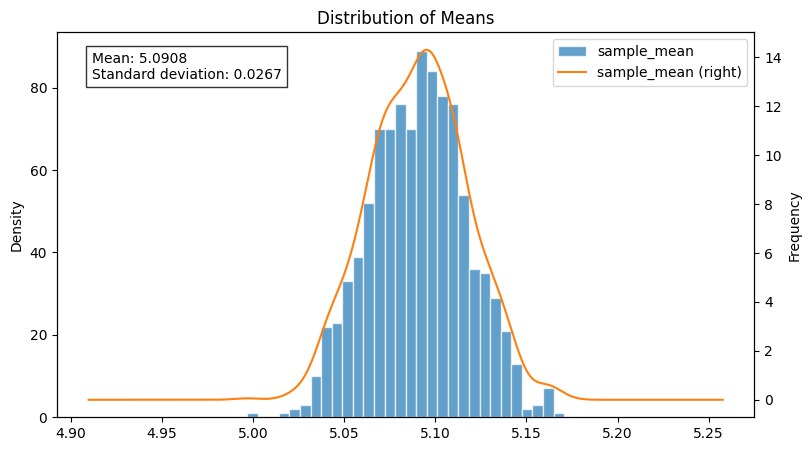

In [22]:
# distribution of results_table
ax = results_table.plot.hist(
    y='sample_mean',
    bins=30,
    figsize=(9, 5),
    alpha=0.7,
    edgecolor='white'
)
results_table.plot.density(
    y='sample_mean',
    ax=ax,
    secondary_y=True,
)

# Calculate mean and standard deviation
mean = results_table['sample_mean'].mean()
std = results_table['sample_mean'].std()

# Create the label text
label_text = f'Mean: {mean:.4f}\nStandard deviation: {std:.4f}'

# Add the label to the plot
plt.text(
    0.05,
    0.95,
    label_text,
    transform=ax.transAxes,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

# Add labels and title
plt.xlabel('Means')
plt.ylabel('Frequency')
plt.title('Distribution of Means')

# Remove gridlines
plt.grid(False)

plt.show()

# Task 3 Probability

In [23]:
# Task 3 answered
# Q1
mean = airline_stats['pct_atc_delay'].mean()
std = airline_stats['pct_atc_delay'].std()
z_1 = (5 - mean) / std
probability_1 = norm.cdf(z_1)
print(f'Probability that pct_atc_delay is less than 5%: {probability_1:.6%}')

Probability that pct_atc_delay is less than 5%: 49.239458%


In [24]:
# Q2
percentile = norm.ppf(0.90)
x_4 = mean + percentile * std
print(f'The 90th percentile of pct_atc_delay is: {x_4:.4f}%')

The 90th percentile of pct_atc_delay is: 11.1372%


In [25]:
# Q3
z_lower = norm.ppf(0.30)
z_upper = norm.ppf(0.70)

x_lower = mean + z_lower * std
x_upper = mean + z_upper * std

print(f'The middle 40% of pct_atc_delay falls between {x_lower:.4f}% and {x_upper:.4f}%')

The middle 40% of pct_atc_delay falls between 2.6155% and 7.5644%
